<br>

# MNIST-Predictive-Pipeline 

## Miniprojeto Módulo 2

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [ ]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [ ]:
# Carregando dataset MNIST

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando as features da variável alvo
X, y = mnist.data, mnist.target

# Exibindo a dimensionalidade da matriz X e do vetor y
print(f"Dimensionalidade de X (Features): {X.shape}")
print(f"Dimensionalidade de y (Rótulos): {y.shape}")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade de X (Features): (70000, 784)
Dimensionalidade de y (Rótulos): (70000,)


Separação Antecipada de Features (X) e Variável Alvo (y):

A separação imediata da base de dados entre a matriz de características ($X$, representando os pixels) e o vetor de rótulos ($y$, representando as classes) logo após o carregamento é uma boa prática arquitetural em Machine Learning, justificada por dois motivos técnicos principais:

1. Proteção e Isolamento no Pré-processamento: Garante que as transformações matemáticas exigidas na Fase 2 (como a normalização das features para a escala de 0.0 a 1.0) sejam aplicadas estritamente aos dados de entrada ($X$). Manter as variáveis separadas evita o risco de corromper acidentalmente os rótulos reais ($y$) durante operações matriciais.  

2. Requisito para Divisão Estratificada: Funções de particionamento, como o train_test_split da biblioteca scikit-learn, exigem que os dados e os rótulos sejam passados como argumentos distintos para sincronizar o embaralhamento. Além disso, ter o vetor $y$ isolado no escopo global é um pré-requisito para alimentar o parâmetro de estratificação (stratify=y), assegurando a proporcionalidade correta das classes (dígitos de 0 a 9) nos conjuntos de treino, validação e teste.

Distribuição das amostras por classe (dígito):
Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


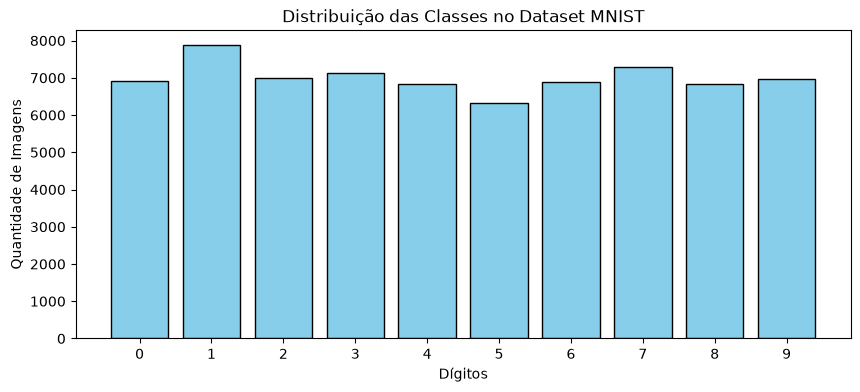

In [2]:
# Verificando balanceamento do dataset

# Analisando a distribuição das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)

print("Distribuição das amostras por classe (dígito):")
for classe, contagem in zip(classes, contagens):
    print(f"Dígito {classe}: {contagem} imagens")

# Visualização gráfica
plt.figure(figsize=(10, 4))
plt.bar(classes, contagens, color='skyblue', edgecolor='black')
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xlabel("Dígitos")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [3]:
# Calculando a dispersão estatística da distribuição de classes
media_amostras = np.mean(contagens)
desvio_padrao = np.std(contagens)
coeficiente_variacao = (desvio_padrao / media_amostras) * 100

print(f"Média de amostras por classe: {media_amostras:.0f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Coeficiente de Variação (CV): {coeficiente_variacao:.2f}%")

Média de amostras por classe: 7000
Desvio Padrão: 378.82
Coeficiente de Variação (CV): 5.41%


Um coeficiente de variação igual a 5.41% é considerado um indicador de baixa dispersão e alta homogeneidade estrutural. Assim, confirma-se que o dataset está balanceado.

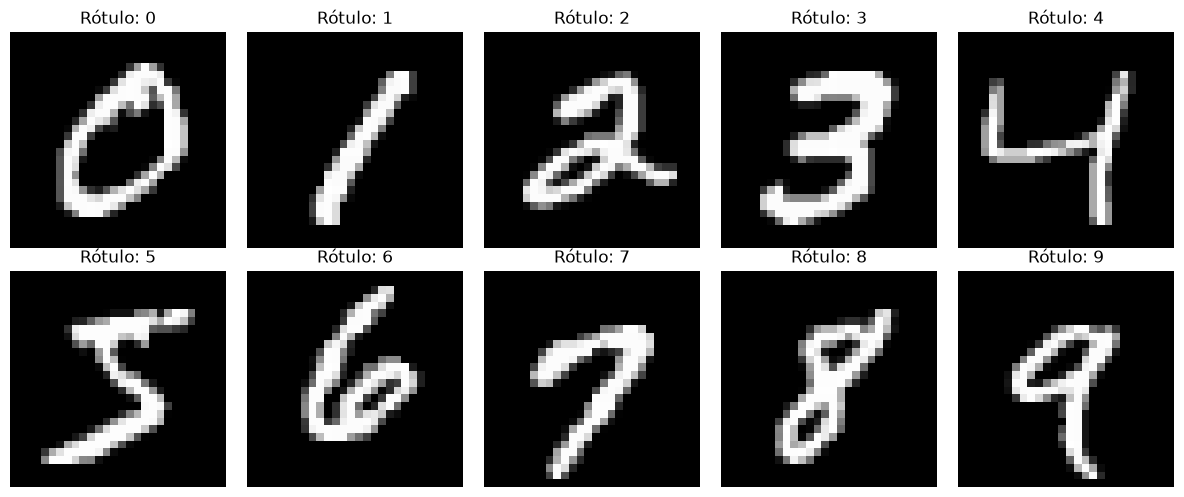

In [4]:
# Exemplos de imagens de cada dígito com seus respectivos rótulos

# Criando uma figura com 2 linhas e 5 colunas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Iterando sobre os dígitos de 0 a 9 para buscar o primeiro exemplo de cada
for classe in range(10):
    # Encontra o índice da primeira ocorrência da classe atual
    indice_imagem = np.where(y == str(classe))[0][0]
    
    # Extrai o vetor de 784 features e remodela para matriz 28x28
    imagem_28x28 = X[indice_imagem].reshape(28, 28)
    
    # Define a posição do subplot (linha e coluna)
    linha = classe // 5
    coluna = classe % 5
    
    # Plota a imagem em escala de cinza
    axes[linha, coluna].imshow(imagem_28x28, cmap='gray')
    axes[linha, coluna].set_title(f"Rótulo: {classe}")
    axes[linha, coluna].axis('off')

plt.tight_layout()
plt.show()

### Interpretação da Estrutura dos Dados


<u>Escala de Intensidade de Pixels (0 a 255)</u>

As imagens do dataset MNIST são monocromáticas (escala de cinza). Computacionalmente, isso significa que cada pixel não possui múltiplos canais de cor (como o RGB), mas sim um único valor numérico inteiro que varia de 0 a 255. Nesta escala de intensidade matemática:

1. O valor 0 representa a ausência total de luz (preto absoluto, geralmente o fundo da imagem).
2. O valor 255 representa a intensidade luminosa máxima (branco absoluto, geralmente o traço principal do dígito).
3. Os valores intermediários (1 a 254) formam as transições suaves e as bordas (tons de cinza).


<u>Representação Vetorial (Transformação de $28\times28$ para 784 features)</u>

Embora a natureza geométrica original de cada imagem seja uma grade bidimensional (uma matriz de 28 linhas por 28 colunas), os algoritmos clássicos de Machine Learning (como SVM e Random Forest) exigem que os dados de entrada sejam unidimensionais.
Para resolver isso, a matriz $28\times28$ passa por um processo de "achatamento" (flattening), onde as linhas de pixels são concatenadas lado a lado. Como $28 \times 28 = 784$, o resultado é um único vetor contendo 784 posições. Portanto, cada "feature" (coluna no nosso conjunto $X$) representa a intensidade de luz de um pixel específico localizado em um ponto exato do desenho original. 